In [1]:
import csv

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

# 各パス指定

In [2]:
dataset = 'model/keypoint_classifier/keypoint.csv'
model_save_path = 'model/keypoint_classifier/keypoint_classifier.keras'

# 分類数設定

In [3]:
NUM_CLASSES = 26

# 学習データ読み込み

In [4]:
X_dataset = np.loadtxt(dataset, delimiter=',', dtype='float32', usecols=list(range(1, (21 * 2) + 1)))

In [5]:
y_dataset = np.loadtxt(dataset, delimiter=',', dtype='int32', usecols=(0))

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_dataset, y_dataset, train_size=0.75, random_state=RANDOM_SEED)

# モデル構築

In [7]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input((21 * 2, )),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

In [8]:
model.summary()  # tf.keras.utils.plot_model(model, show_shapes=True)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dropout (Dropout)                    │ (None, 42)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           2,752 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 26)                  │             858 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,690 (22.23 KB)

 Trainable params: 5,690 (22.23 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# モデルチェックポイントのコールバック
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    model_save_path, verbose=1, save_weights_only=False)
# 早期打ち切り用コールバック
es_callback = tf.keras.callbacks.EarlyStopping(patience=20, verbose=1)

In [10]:
# モデルコンパイル
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# モデル訓練

In [11]:
model.fit(
    X_train,
    y_train,
    epochs=100000,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[cp_callback, es_callback]
)

Epoch 1/100000
44/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0298 - loss: 3.3051
Epoch 1: saving model to model/keypoint_classifier/keypoint_classifier.keras
52/52 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.0346 - loss: 3.2937 - val_accuracy: 0.1191 - val_loss: 3.0998
Epoch 2/100000
29/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1065 - loss: 3.0982 
Epoch 2: saving model to model/keypoint_classifier/keypoint_classifier.keras
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1110 - loss: 3.0777 - val_accuracy: 0.1679 - val_loss: 2.8796
Epoch 3/100000
51/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1425 - loss: 2.9127
Epoch 3: saving model to model/keypoint_classifier/keypoint_classifier.keras
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1429 - loss: 2.9107 - val_accuracy: 0.2114 - val_loss: 2.6482
Epoch 4/100000
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1844 - loss: 2.7223
Epoch 4: saving model to model/keypoint_classifier/keypoint_classifier

In [12]:
# モデル評価
val_loss, val_acc = model.evaluate(X_test, y_test, batch_size=128)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8198 - loss: 0.6353 


In [13]:
# 保存したモデルのロード
model = tf.keras.models.load_model(model_save_path)

In [14]:
# 推論テスト
predict_result = model.predict(np.array([X_test[0]]))
print(np.squeeze(predict_result))
print(np.argmax(np.squeeze(predict_result)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
[4.36336249e-02 1.08517765e-04 2.52066151e-04 1.01222629e-02
 2.58945138e-03 9.48483939e-05 6.86218143e-01 7.89497339e-04
 8.93444102e-03 2.12953280e-10 2.23697815e-02 5.66786272e-04
 2.31954025e-10 1.03473184e-07 8.61623557e-04 7.03464001e-02
 1.51282609e-01 3.71601345e-07 5.24968818e-05 9.21783620e-04
 5.02114357e-11 9.97212512e-23 1.37938761e-17 3.11032854e-05
 8.24011571e-04 1.12019760e-11]
6


# 混同行列

70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


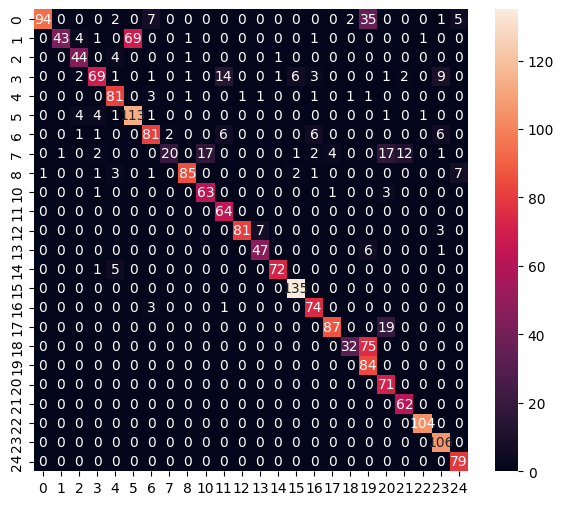

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.64      0.78       146
           1       0.98      0.36      0.52       120
           2       0.80      0.88      0.84        50
           3       0.86      0.63      0.73       110
           4       0.84      0.90      0.87        90
           5       0.62      0.90      0.74       125
           6       0.84      0.79      0.81       103
           7       0.91      0.26      0.40        77
           8       0.96      0.84      0.89       101
          10       0.79      0.93      0.85        68
          11       0.75      1.00      0.86        64
          12       0.99      0.89      0.94        91
          13       0.85      0.87      0.86        54
          14       0.97      0.92      0.95        78
          15       0.94      1.00      0.97       135
          16       0.84      0.95      0.89        78
          17       0.95      0.82      0.88       106
     

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def print_confusion_matrix(y_true, y_pred, report=True):
    labels = sorted(list(set(y_true)))
    cmx_data = confusion_matrix(y_true, y_pred, labels=labels)
    
    df_cmx = pd.DataFrame(cmx_data, index=labels, columns=labels)
 
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(df_cmx, annot=True, fmt='g' ,square=False)
    ax.set_ylim(len(set(y_true)), 0)
    plt.show()
    
    if report:
        print('Classification Report')
        print(classification_report(y_test, y_pred))

Y_pred = model.predict(X_test)
y_pred = np.argmax(Y_pred, axis=1)

print_confusion_matrix(y_test, y_pred)

# Tensorflow-Lite用のモデルへ変換

In [16]:
# 推論専用のモデルとして保存
model.save(model_save_path, include_optimizer=False)

In [17]:
# モデルを変換(量子化)
tflite_save_path = 'model/keypoint_classifier/keypoint_classifier.tflite'

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quantized_model = converter.convert()

open(tflite_save_path, 'wb').write(tflite_quantized_model)

INFO:tensorflow:Assets written to: C:\Users\USER\AppData\Local\Temp\tmpvql5vn4e\assets


INFO:tensorflow:Assets written to: C:\Users\USER\AppData\Local\Temp\tmpvql5vn4e\assets


Saved artifact at 'C:\Users\USER\AppData\Local\Temp\tmpvql5vn4e'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 42), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 26), dtype=tf.float32, name=None)
Captures:
  1250423290960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1250423288272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1250429291984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1250429293136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1250429304656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1250429302928: TensorSpec(shape=(), dtype=tf.resource, name=None)


11848

# 推論テスト

In [18]:
interpreter = tf.lite.Interpreter(model_path=tflite_save_path)
interpreter.allocate_tensors()

In [19]:
# 入出力テンソルを取得
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

In [20]:
interpreter.set_tensor(input_details[0]['index'], np.array([X_test[0]]))

In [21]:
%%time
# 推論実施
interpreter.invoke()
tflite_results = interpreter.get_tensor(output_details[0]['index'])

CPU times: total: 0 ns
Wall time: 2 ms


In [22]:
print(np.squeeze(tflite_results))
print(np.argmax(np.squeeze(tflite_results)))

[4.4093888e-02 1.0713325e-04 2.5269153e-04 1.0127137e-02 2.4942779e-03
 9.1399656e-05 6.8296736e-01 7.6648034e-04 9.1228150e-03 1.8807775e-10
 2.2368621e-02 5.4836919e-04 1.8732091e-10 8.5941856e-08 8.3864370e-04
 7.0379592e-02 1.5409896e-01 3.0670017e-07 4.9180042e-05 8.6628320e-04
 4.2311099e-11 6.4657867e-23 1.0337173e-17 2.6874271e-05 7.9988758e-04
 9.5631428e-12]
6
